In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [2]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path) / 'sp_map_to_sc_Epi'

######### saved from Fig2_1_sp_map_to_sc.ipynb
file_name = 'UGE_sp_added_time.h5ad'
adata_sp_time = sc.read(file_path / file_name)

In [3]:
### Please run ./spatial_nrb_src/get_nrb_prop.py first to get ./spatial_nrb_src/output/prop_adata_diseases.h5ad
prop_adata = sc.read('./spatial_nrb_src/output/prop_adata_diseases.h5ad')

In [5]:
prop_df = adata_sp_time.obs.merge(prop_adata.to_df(), left_index = True, right_index = True)
prop_df = prop_df.sort_values('time')
prop_df.columns

Index(['sample', 'patient', 'cell_id', 'sample_type', 'sample_affect',
       'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT',
       'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank',
       'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid',
       'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA',
       'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword',
       'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes',
       'pred_atlas', 'predict_mapped_ct_anno_prob', 'Slides', 'time',
       'Monocyte-derived Mph', 'EC venous systemic', 'FB ECM SOX4+',
       'CD4 T cells', 'FB ECM', 'Plasma cells', 'EC general capillary', 'AT2',
       'myo-FB', 'Pericytes', 'CD8 T cells', 'Ciliated', 'SMCs', 'FB COL1A1+',
       'SCGB3A1+/SCGB3A2+', 'FB HAS1+', 'B cells', 'Basal', 'EC arterial',
       'Aberrant Basaloid', 'AT1', 'Mast cells', 'Alveolar macrophages',
       'Interstitial Mph perivascular', 'DC2', 'Lymphatic EC

In [6]:
neighbor_cts = [
    'EC venous systemic', 'Monocyte-derived Mph', 'FB ECM SOX4+',
       'CD4 T cells', 'FB ECM', 'Plasma cells', 'EC general capillary', 'AT2',
       'CD8 T cells', 'myo-FB', 'Pericytes', 'SMCs', 'FB COL1A1+',
       'SCGB3A1+/SCGB3A2+', 'B cells', 'FB HAS1+', 'Aberrant Basaloid',
       'Basal', 'EC arterial', 'AT1', 'Mast cells',
       'Alveolar macrophages', 'Ciliated', 'DC2',
       'Interstitial Mph perivascular', 'Lymphatic EC mature',
       'Classical monocytes', 'EC aerocyte capillary', 'FB ECM CHI3L2+',
       'SMG duct', 'NK cells', 'FB ECM COL1A1+', 'Non-classical monocytes',
       'SCGB1A1+/SCGB3A1+/SCGB3A2+', 'FB', 'Plasmacytoid DCs', 'Mesothelial',
       'Alveolar Mph CCL3+', 'Migratory DCs', 'Ionocyte', 'Secretory MUC5B+',
       'Suprabasal SCGB1A1+', 'Alveolar Mph proliferating', 'DC1'
]

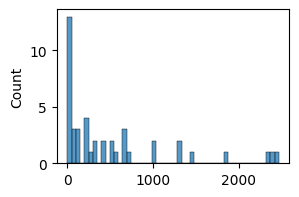

In [7]:
arr = prop_df.loc[:, neighbor_cts].sum(0)
fig, axs = plt.subplots(1, 1, figsize=(3, 2), gridspec_kw={'wspace': .5, 'hspace': 0.2})
sns.histplot(arr, bins = 50)
plt.show()
plt.close()


In [8]:
arr = prop_df.loc[:, neighbor_cts].sum(0)
arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000]

/tmp/ipykernel_3454370/1009681128.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000]
/tmp/ipykernel_3454370/1009681128.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000]


AT1                     1011.431568
myo-FB                  1017.950000
Aberrant Basaloid       1284.066759
EC venous systemic      1289.036103
FB ECM SOX4+            1450.488558
FB ECM                  1842.638010
Monocyte-derived Mph    2323.995802
EC general capillary    2368.639551
AT2                     2466.771270
dtype: float64

In [9]:
print(arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000].index.tolist())

['AT1', 'myo-FB', 'Aberrant Basaloid', 'EC venous systemic', 'FB ECM SOX4+', 'FB ECM', 'Monocyte-derived Mph', 'EC general capillary', 'AT2']


/tmp/ipykernel_3454370/4008066406.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000].index.tolist())
/tmp/ipykernel_3454370/4008066406.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(arr[np.argsort(arr)][arr[np.argsort(arr)] > 1000].index.tolist())


In [10]:
vis_cts = [
#     'EC venous systemic', 'myo-FB', 'CD4 T cells',
#     'FB ECM', 'Aberrant Basaloid', 'Monocyte-derived Mph', 'AT2', 'EC general capillary', #'FB ECM SOX4+'
    'FB ECM', 'Aberrant Basaloid', 'Monocyte-derived Mph', 'AT2', 'EC general capillary', #'FB ECM SOX4+'
#     'SCGB3A1+/SCGB3A2+', , 'Basal', 'EC arterial'
]

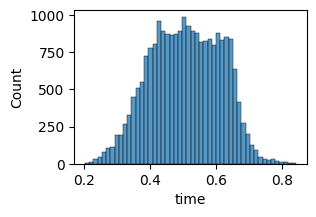

In [11]:
arr = adata_sp_time.obs['time']
# arr = adata_sp_time[adata_sp_time.obs['pred_atlas'] == 'AT1'].obs['time']
fig, axs = plt.subplots(1, 1, figsize=(3, 2), gridspec_kw={'wspace': .5, 'hspace': 0.2})
sns.histplot(arr[arr > .2], bins = 50)
# axs.axvline(x = np.quantile(float_values, .99), color = 'red')
plt.show()
plt.close()


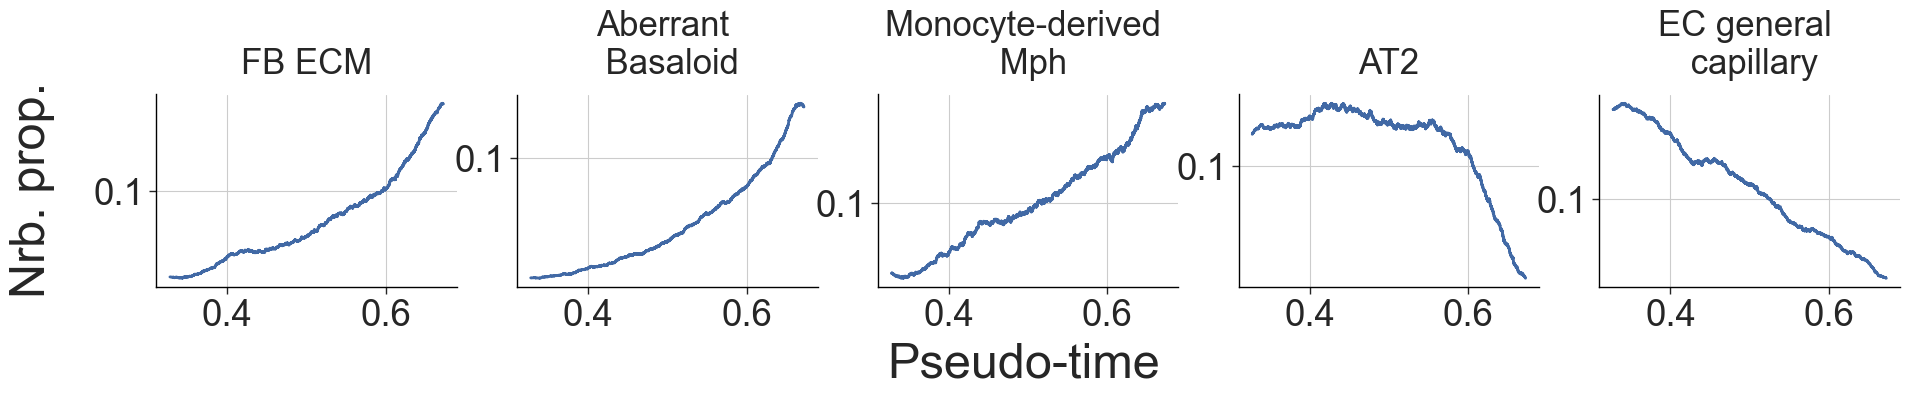

In [12]:
set_vis_default(font = 3)

fig, axs = plt.subplots(
    1, len(vis_cts), 
    figsize=(4.5 * len(vis_cts), 2.5), 
    gridspec_kw={'wspace': .2, 'hspace': 0.9}
)
for i, vis_ct in enumerate(vis_cts):
    ax = axs[i]
    window_size = 2000
    arr = prop_df[vis_ct].values.squeeze()
    smoothed_expression = pd.Series(arr).rolling(window=window_size, center=True).mean()
    valid_indices = smoothed_expression.notna()
    
    ax.plot(prop_df['time'], smoothed_expression, color = '#4169a5', linewidth = 2.)
    
    
    ax.set_yticks([.1])
    ax.set_xticks([.4, .6])

    ax.set_xlabel('')
    ax.set_ylabel('')



    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('black')        
        ax.spines[spine].set_linewidth(1)

    if vis_ct == 'Monocyte-derived Mph':
        vis_ct = f'Monocyte-derived \n Mph'
    elif vis_ct == 'EC general capillary':
        vis_ct = f'EC general \n capillary'
    elif vis_ct == 'Aberrant Basaloid':
        vis_ct = f'Aberrant \n Basaloid'
    
    ax.set_title(vis_ct, fontsize = 25, pad = 15)
#     plt.axvline(x = .2, color = 'red')
#     plt.axvline(x = .52, color = 'red')

fig.text(0.06, 0.5, 'Nrb. prop.', va='center', rotation='vertical', fontsize=35)
fig.text(0.45, -0.2, f'Pseudo-time', va='center', rotation='horizontal', fontsize=35)

# plt.savefig(f'./save_figs/nrb_prop_change_horizontal.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.1)

plt.show()
plt.close()